Alexander W. Criswell 2/16/25

Short notebook to account for Poisson statistics and estimate p(det) from the rates.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy import units as u
from astropy import constants as const

SNR $\ge3$:

In [2]:
## from multiband-analysis-notebook-final.ipynb
lisa_rate_snr3_2050 = 1.18e-4 # yr^-1
lisa_rate_snr3_2100 = 1.48e-3 # yr^-1
rate_snr3_2050 = 7.40e-4 # yr^-1
rate_snr3_2100 = 4.97e-3 # yr^-1
lisa_t_conservative = 4 # yrs
lisa_t_optimistic = 10 # yrs
t_conservative = 12.65 # yrs
t_optimistic = 24.65 # yrs

In [3]:
snr3_2050_cdist = st.poisson(rate_snr3_2050*t_conservative)
snr3_2050_odist = st.poisson(rate_snr3_2050*t_optimistic)
snr3_2100_cdist = st.poisson(rate_snr3_2100*t_conservative)
snr3_2100_odist = st.poisson(rate_snr3_2100*t_optimistic)
lisa_snr3_2050_cdist = st.poisson(lisa_rate_snr3_2050*t_conservative)
lisa_snr3_2050_odist = st.poisson(lisa_rate_snr3_2050*t_optimistic)
lisa_snr3_2100_cdist = st.poisson(lisa_rate_snr3_2100*t_conservative)
lisa_snr3_2100_odist = st.poisson(lisa_rate_snr3_2100*t_optimistic)

In [4]:
## estimate total p(Ndet > 0) via monte carlo
Ndraws = 100000
pdet = []
for dist in [snr3_2050_cdist,snr3_2050_odist,snr3_2100_cdist,snr3_2100_odist,
             lisa_snr3_2050_cdist,lisa_snr3_2050_odist,lisa_snr3_2100_cdist,lisa_snr3_2100_odist]:
    draws = dist.rvs(Ndraws)
    pdet.append(np.sum(draws>0)/Ndraws)

In [5]:
pdet

[np.float64(0.00967),
 np.float64(0.01821),
 np.float64(0.06107),
 np.float64(0.11614),
 np.float64(0.00136),
 np.float64(0.00291),
 np.float64(0.01916),
 np.float64(0.03561)]

In [6]:
Ntrials = 1000
Ndraws = int(1e6)
pdet_tests = np.empty((8,Ntrials))
for i in tqdm(range(Ntrials)):
    for j, dist in enumerate([snr3_2050_cdist,snr3_2050_odist,snr3_2100_cdist,snr3_2100_odist,
                              lisa_snr3_2050_cdist,lisa_snr3_2050_odist,lisa_snr3_2100_cdist,lisa_snr3_2100_odist]):
        draws = dist.rvs(Ndraws)
        pdet_tests[j,i] = np.sum(draws>0)/Ndraws

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:33<00:00, 10.71it/s]


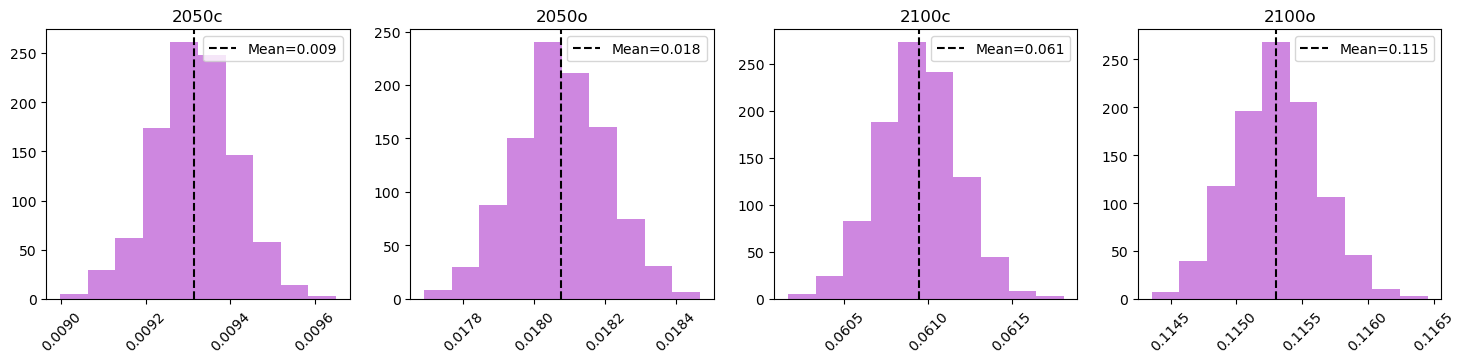

In [7]:
names = ['2050c','2050o','2100c','2100o']
fig, axes = plt.subplots(1,4,figsize=(18,3.5))
for j in range(4):
    axes[j].hist(pdet_tests[j,:],color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(pdet_tests[j,:])
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

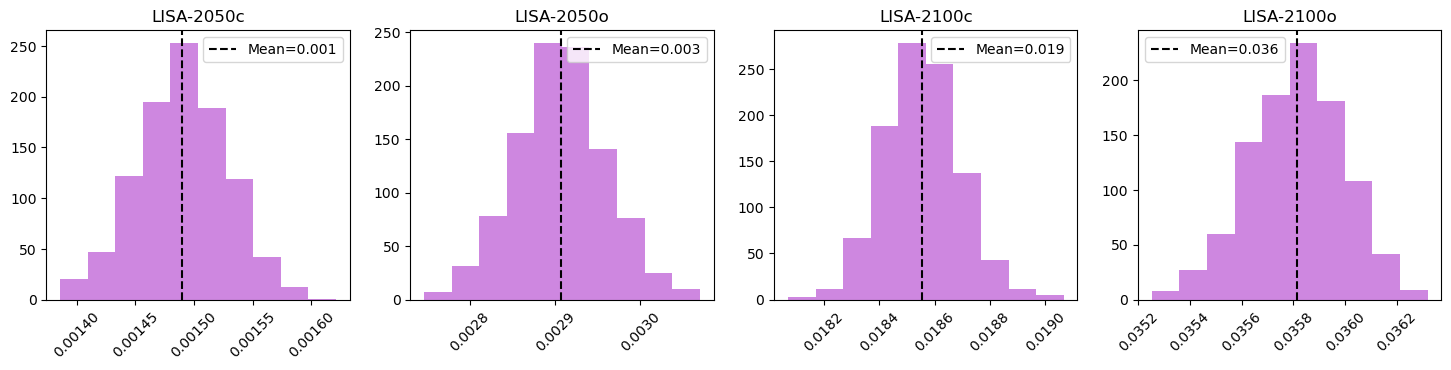

In [8]:
names = ['LISA-2050c','LISA-2050o','LISA-2100c','LISA-2100o']
fig, axes = plt.subplots(1,4,figsize=(18,3.5))
for j in range(4):
    axes[j].hist(pdet_tests[j+4,:],color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(pdet_tests[j+4,:])
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

Looking at prevalence of missed multiband mergers:

In [16]:
max_deltat = (10*u.kpc/const.c).to(u.yr).value
ratedr3 = 1/65000 ## yr^-1
rate2050 = 1/1350 ## yr^-1
missed_dist_dr3like = st.poisson(max_deltat*ratedr3)
missed_dist_2050 = st.poisson(max_deltat*rate2050)

In [17]:
Ntrials = 1000
Ndraws = int(1e5)
present_tests = np.empty((2,Ntrials))
counts_tests = np.empty((2,Ntrials,Ndraws))
for i in tqdm(range(Ntrials)):
    for j, dist in enumerate([missed_dist_dr3like,missed_dist_2050]):
        draws = dist.rvs(Ndraws)
        present_tests[j,i] = np.sum(draws>0)/Ndraws
        counts_tests[j,i,:] = draws

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 197.21it/s]


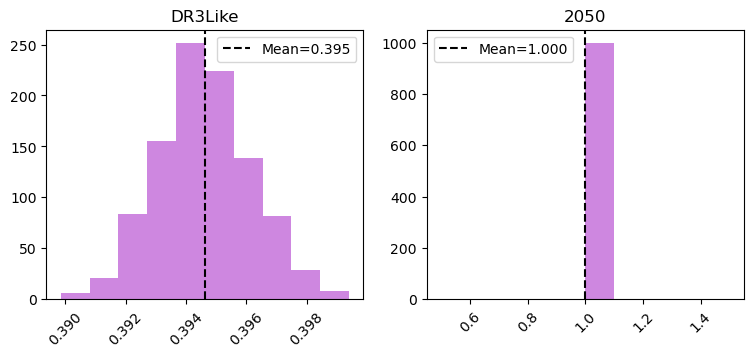

In [18]:
names = ['DR3Like','2050']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(present_tests[j,:],color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(present_tests[j,:])
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

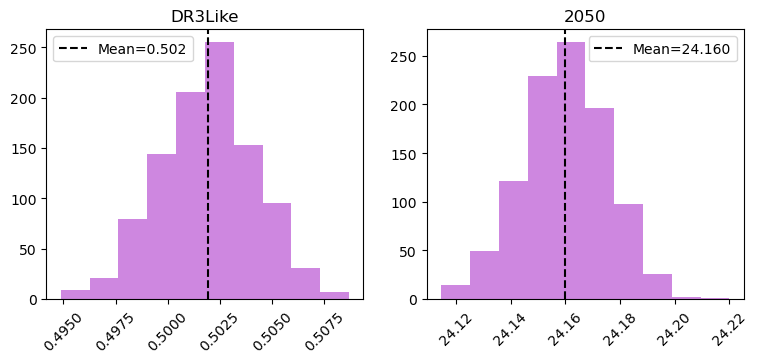

In [19]:
names = ['DR3Like','2050']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(np.mean(counts_tests[j,:,:],axis=-1),color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(np.mean(counts_tests[j,:,:],axis=-1),axis=-1)
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

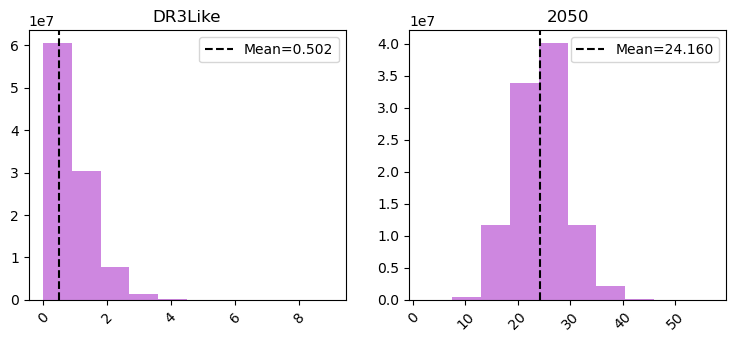

In [20]:
names = ['DR3Like','2050']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(counts_tests[j,:,:].flatten(),color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(np.mean(counts_tests[j,:,:],axis=-1),axis=-1)
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

In [31]:
np.sum(counts_tests[0,:,:].flatten() >0)/counts_tests[0,:,:].size

np.float64(0.39463138)

In [21]:
np.quantile(counts_tests[0,:,:].flatten(),[0.05,0.5,0.95])

array([0., 0., 2.])

In [22]:
np.quantile(counts_tests[1,:,:].flatten(),[0.05,0.5,0.95])

array([16., 24., 33.])

Repeat this for SNR 7 given no counterpart:

In [23]:
snr7_ratedr3 = 1/542030 ## yr^-1
snr7_rate2050 = 1/4610 ## yr^-1
snr7_missed_dist_dr3like = st.poisson(max_deltat*snr7_ratedr3)
snr7_missed_dist_2050 = st.poisson(max_deltat*snr7_rate2050)

In [24]:
Ntrials = 1000
Ndraws = int(1e5)
snr7_present_tests = np.empty((2,Ntrials))
snr7_counts_tests = np.empty((2,Ntrials,Ndraws))
for i in tqdm(range(Ntrials)):
    for j, dist in enumerate([snr7_missed_dist_dr3like,snr7_missed_dist_2050]):
        draws = dist.rvs(Ndraws)
        snr7_present_tests[j,i] = np.sum(draws>0)/Ndraws
        snr7_counts_tests[j,i,:] = draws

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 183.05it/s]


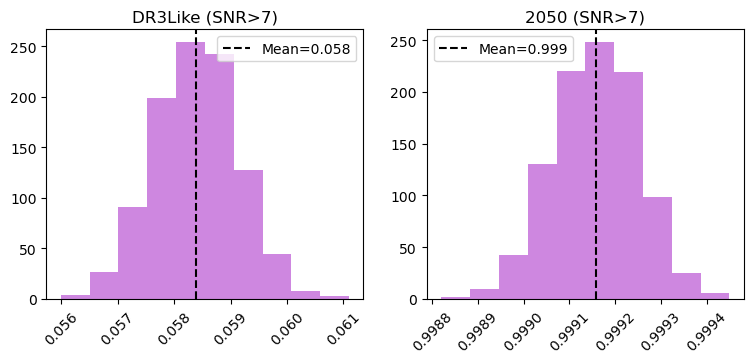

In [26]:
names = ['DR3Like (SNR>7)','2050 (SNR>7)']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(snr7_present_tests[j,:],color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(snr7_present_tests[j,:])
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

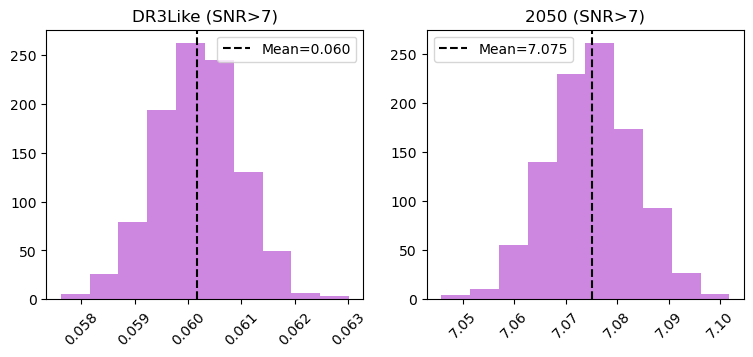

In [27]:
names = ['DR3Like (SNR>7)','2050 (SNR>7)']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(np.mean(snr7_counts_tests[j,:,:],axis=-1),color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(np.mean(snr7_counts_tests[j,:,:],axis=-1),axis=-1)
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

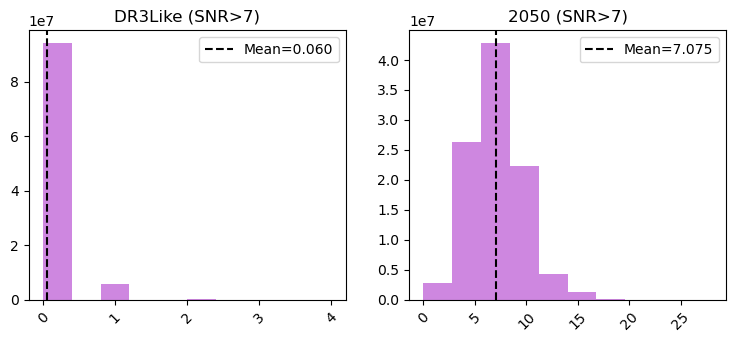

In [28]:
names = ['DR3Like (SNR>7)','2050 (SNR>7)']
fig, axes = plt.subplots(1,2,figsize=(9,3.5))
for j in range(2):
    axes[j].hist(snr7_counts_tests[j,:,:].flatten(),color='mediumorchid',alpha=0.7)
    axes[j].set_title(names[j])
    mean_j = np.mean(np.mean(snr7_counts_tests[j,:,:],axis=-1),axis=-1)
    axes[j].axvline(mean_j,ls='--',label='Mean={:0.3f}'.format(mean_j),c='k')
    axes[j].legend()
    axes[j].tick_params("x",rotation=45)
plt.show()

In [29]:
np.quantile(snr7_counts_tests[0,:,:].flatten(),[0.05,0.5,0.95])

array([0., 0., 1.])

In [30]:
np.quantile(snr7_counts_tests[1,:,:].flatten(),[0.05,0.5,0.95])

array([ 3.,  7., 12.])